In [3]:
# Fig 5 heatmap raster
# Fig 5 compare sync vs async, layers, cell types

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import pickle
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
import statistics

%matplotlib inline

matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['pdf.fonttype'] = 42 # enables editing of strings of characters rather than individual characters
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

In [5]:
dir = os.getcwd()
base_dir = os.path.dirname(dir)
data_dir = os.path.join(base_dir, 'data')

In [6]:
laser_samp_dir = os.path.join(data_dir, 'sync_samp')
recording_groups = ['TrkC','TrkB','TrkC_S1HP','TrkB_S1HP']

In [7]:
male_list = ['BRC2','BRC5','BRN5','BTT1','BTT3','BPO5','BPU4','BQD3','BTK4','BTM2','BTM3']
female_list = ['BQQ4','BRD2','BRO3','BRO4','BUF4','BPP1','BPV4','BPV5','BQE3','BTN4','BTR5']

sex_map = {name: 'Male' for name in male_list}
sex_map.update({name: 'Female' for name in female_list})

In [8]:
# load data
units_select_groups = {}
nunits_cum_sum_layer_groups = {}
units_select_maxpad_sync = {}
units_select_maxpad_async = {}
units_select_maxpad_sync_bydepth = {}
units_select_maxpad_async_bydepth = {}

allunits_samp_dur = {} # waveform duration - all units

for igroup in recording_groups:
    units_select_file_igroup = os.path.join(data_dir, 'units_select_'+igroup+'.npy')
    nunits_cum_sum_layer_file_igroup =os.path.join(data_dir, 'nunits_cum_sum_layer_'+igroup+'.npy')
    units_select_maxpad_sync_bydepth_file_igroup = os.path.join(data_dir, 'units_select_maxpad_sync_'+igroup+'_bydepth.npy')
    units_select_maxpad_async_bydepth_file_igroup = os.path.join(data_dir, 'units_select_maxpad_async_'+igroup+'_bydepth.npy')

    units_select_groups[igroup] = np.load(units_select_file_igroup)
    nunits_cum_sum_layer_groups[igroup] = np.load(nunits_cum_sum_layer_file_igroup)
    units_select_maxpad_sync_bydepth[igroup] = np.load(units_select_maxpad_sync_bydepth_file_igroup)
    units_select_maxpad_async_bydepth[igroup] = np.load(units_select_maxpad_async_bydepth_file_igroup)

    allunits_samp_dur_file_igroup = os.path.join(data_dir, 'spk_dur_samp_'+igroup+'.npy')
    allunits_samp_dur[igroup] = np.load(allunits_samp_dur_file_igroup)


In [9]:
# unit ID in selected units - not in raw units for RS vs FS units
fs = 30000
dur_cutoff_samp = 0.55 / 1000 * fs # cutoff for

units_selected_FS = {}
units_selected_RS = {}
units_selected_type = {} # list of FS/RS for each unit

for igroup in recording_groups:
    nunits_select = len(units_select_groups[igroup])
    units_select_dur_samp_igroup = allunits_samp_dur[igroup][units_select_groups[igroup]]
    units_selected_FS_igroup = np.where(units_select_dur_samp_igroup < dur_cutoff_samp)[0] # unit ID in selected units - not in raw units
    units_selected_RS_igroup = np.where(units_select_dur_samp_igroup > dur_cutoff_samp)[0] # unit ID in selected units - not in raw units

    units_selected_FS[igroup] = units_selected_FS_igroup
    units_selected_RS[igroup] = units_selected_RS_igroup

    units_type_list = []
    for i in range(nunits_select):
        if i in units_selected_FS_igroup:
            units_type_list.append('FS')
        elif i in units_selected_RS_igroup:
            units_type_list.append('RS')

    units_selected_type[igroup] = units_type_list


In [10]:
# load the laser time for sync_set 0 (re-saved 2025/12/10)
fs_laser = 30000
sync_laser_isi = int(0.8/1000*fs_laser)
laser_samp_sync_sets = {}
laser_samp_async_sets = {}

for iset in range(1):
    
    sync_samp_file = 'sync_samp_set'+str(iset)+'.npy'
    async_samp_file = 'async_samp_set'+str(iset)+'.npy'

    laser_samp_sync_file = os.path.join(laser_samp_dir, sync_samp_file)
    laser_samp_async_file = os.path.join(laser_samp_dir, async_samp_file)

    laser_samp_sync = np.load(laser_samp_sync_file)
    laser_samp_async = np.load(laser_samp_async_file)

    laser_samp_sync_sets[iset] = laser_samp_sync
    laser_samp_async_sets[iset] = laser_samp_async

C:\Users\ajemanu\AppData\Local\Temp\ipykernel_34840\195433343.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])


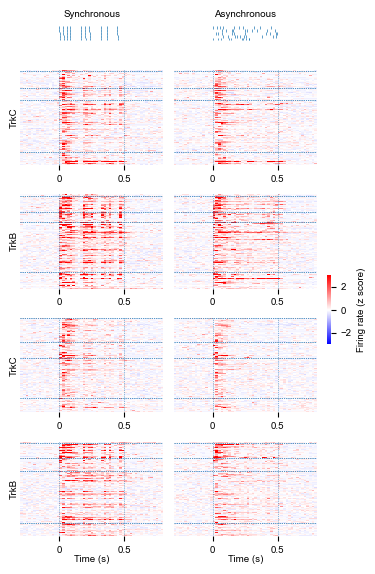

In [11]:
### plot examples of sync vs async - one pad only - all 4 groups - add traces

f, ax = plt.subplots(5,2,figsize=[3.45,5.75],gridspec_kw={'height_ratios':[1,6,6,6,6]})

for i, igroup in enumerate(recording_groups):
  
  sns.heatmap(units_select_maxpad_sync_bydepth[igroup], ax=ax[i+1,0], vmin=-3, vmax=3, cbar=False, cmap = 'bwr')
  sns.heatmap(units_select_maxpad_async_bydepth[igroup], ax=ax[i+1,1], vmin=-3, vmax=3, cbar=False, cmap = 'bwr')
  
  for j in [0,1]:
    ax[i+1,j].vlines(50, 0, len(units_select_groups[igroup]), linestyles= ':', linewidth = 0.5)
    ax[i+1,j].vlines(75, 0, len(units_select_groups[igroup]), linestyles= ':', linewidth = 0.5)
    ax[i+1,j].hlines(nunits_cum_sum_layer_groups[igroup][:-1], 0, 100, linestyles= ':', linewidth = 0.5)
    ax[i+1,j].hlines(nunits_cum_sum_layer_groups[igroup][:-1], 0, 100, linestyles= ':', linewidth = 0.5)

for i in np.arange(2,10):
  ax[i//2, i%2].set_xlim(35,90)
  ax[i//2, i%2].set_xticks([])
  ax[i//2, i%2].set_yticks([])
  ax[i//2, i%2].set_ylabel('')
  ax[i//2, i%2].set_xticks(ticks=[50,75], labels=[0,0.5], rotation = 0)

### plot traces
yplot = 0
sync_set = 0
laser_samp_sync = laser_samp_sync_sets[sync_set]  # load the laser_samp for the file
laser_samp_async = laser_samp_async_sets[sync_set]

for itrace in range(5): # 5 traces
    itrace_laser_time_sync  = laser_samp_sync[itrace,:] / fs_laser
    itrace_laser_time_async = laser_samp_async[itrace,:] / fs_laser
    ax[0,0].vlines(itrace_laser_time_sync,  ymin=yplot,ymax=yplot+1,color='#1f77b4', linewidth=0.5)
    ax[0,1].vlines(itrace_laser_time_async, ymin=yplot,ymax=yplot+1,color='#1f77b4', linewidth=0.5)
    yplot += 1

for i in np.arange(0,2):
  ax[i//2, i%2].set_xlim(-0.3,0.8)
  ax[i//2, i%2].set_xticks([])
  ax[i//2, i%2].set_yticks([])
  ax[i//2, i%2].invert_yaxis()
  ax[i//2, i%2].spines['top'].set_visible(False)
  ax[i//2, i%2].spines['right'].set_visible(False)
  ax[i//2, i%2].spines['bottom'].set_visible(False)
  ax[i//2, i%2].spines['left'].set_visible(False)

ax[0,0].set_title('Synchronous', fontsize=7)  
ax[0,1].set_title('Asynchronous', fontsize=7) 
ax[4,0].set_xlabel('Time (s)', labelpad=0)
ax[4,1].set_xlabel('Time (s)', labelpad=0)

ax[1,0].set_ylabel('TrkC', labelpad=1)
ax[2,0].set_ylabel('TrkB', labelpad=1)

ax[3,0].set_ylabel('TrkC', labelpad=1)
ax[4,0].set_ylabel('TrkB', labelpad=1)

norm = plt.Normalize(vmin=-3, vmax=3)
sm = plt.cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([]) # an empty array is sufficient

cbar_ax = f.add_axes([0.95, 0.40, 0.01, 0.12]) # [left, bottom, width, height]
cbar = f.colorbar(sm, cbar_ax, label='Firing rate (z score)')
cbar.outline.set_visible(False)
plt.subplots_adjust(hspace=0.1, wspace=0.2)
plt.tight_layout(rect=[0, 0, 0.95, 1])

# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures2\Fig5A_heatmap_sync_async_traces.pdf",dpi=600,bbox_inches='tight',transparent=True)

plt.show()

In [12]:
# load saved dataframes
mfr_dfs = {}
mfr_mice_dfs = {}
for i,igroup in enumerate(recording_groups):
    mfr_df_file_igroup = os.path.join(data_dir, 'mfr_df_'+ igroup +'.csv')
    mfr_df_animals_file_igroup = os.path.join(data_dir, 'mfr_df_animals_'+ igroup +'.csv')
    mfr_df_igroup = pd.read_csv(mfr_df_file_igroup)
    mfr_mice_df_igroup = pd.read_csv(mfr_df_animals_file_igroup)
    mfr_df_igroup['genoGroup'] = igroup
    mfr_mice_df_igroup['genoGroup'] = igroup
    mfr_df_igroup['unitID'] = mfr_df_igroup['unitID'].astype(int)
    mfr_df_igroup['unitGroup'] = mfr_df_igroup['genoGroup']+'_'+mfr_df_igroup['unitID'].astype(str) # unique Genotype group + unitID for each unit

    mfr_dfs[igroup] = mfr_df_igroup
    mfr_mice_dfs[igroup] = mfr_mice_df_igroup
    
mfr_df_concat = pd.concat(mfr_dfs)
mfr_mice_df_concat = pd.concat(mfr_mice_dfs)

# separate into FP and HP
mfr_df_FP = mfr_df_concat[mfr_df_concat['genoGroup'].isin(['TrkC','TrkB'])]
mfr_df_HP = mfr_df_concat[mfr_df_concat['genoGroup'].isin(['TrkC_S1HP','TrkB_S1HP'])]

mfr_mice_df_FP = mfr_mice_df_concat[mfr_mice_df_concat['genoGroup'].isin(['TrkC','TrkB'])]
mfr_mice_df_HP = mfr_mice_df_concat[mfr_mice_df_concat['genoGroup'].isin(['TrkC_S1HP','TrkB_S1HP'])]

In [13]:
### load raw FR for max pad (units_select), baseline fr (all units) - dict
units_max_pad_groups = {}

units_base_fr = {}
units_maxpad_z_sync = {}
units_maxpad_z_async = {}
units_maxpad_fr_sync = {}
units_maxpad_fr_async = {}

for igroup in recording_groups:
    units_max_pad_file_igroup = os.path.join(data_dir, 'units_max_pad_'+ igroup +'.npy')
    units_select_base_file_igroup = os.path.join(data_dir, 'units_select_base_fr_'+ igroup +'.npy')

    units_select_maxpad_fr_sync_file = os.path.join(data_dir, 'units_select_maxpad_fr_sync_'+ igroup +'.npy')
    units_select_maxpad_fr_async_file = os.path.join(data_dir, 'units_select_maxpad_fr_async_'+ igroup +'.npy')

    units_max_pad_groups[igroup] = np.load(units_max_pad_file_igroup)
    units_base_fr[igroup] = np.load(units_select_base_file_igroup)

    units_maxpad_fr_sync[igroup] = np.load(units_select_maxpad_fr_sync_file)
    units_maxpad_fr_async[igroup] = np.load(units_select_maxpad_fr_async_file)   


In [14]:
# calculate the change in firing rates (raw FR - baseline FR)
ntbins = units_maxpad_fr_sync['TrkC'].shape[1]

tbins_stim1 = 50
tbins_stim2 = 75
tbins_on1 = 50
tbins_on2 = 53
tbins_sus1 = 60
tbins_sus2 = 75

units_dfr_sync = {}
units_dfr_async = {}

units_dfr_sync_on = {}
units_dfr_async_on = {}
units_dfr_sync_sus = {}
units_dfr_async_sus = {}

for igroup in recording_groups:
    units_base_mat_igroup = np.tile(units_base_fr[igroup], (ntbins,1)).T # repeat to the same shape as fr
    units_dfr_sync_igroup = units_maxpad_fr_sync[igroup] - units_base_mat_igroup
    units_dfr_async_igroup = units_maxpad_fr_async[igroup] - units_base_mat_igroup

    units_dfr_sync[igroup] = units_dfr_sync_igroup
    units_dfr_async[igroup] = units_dfr_async_igroup

    units_dfr_sync_on_igroup = np.mean(units_dfr_sync_igroup[:,tbins_on1:tbins_on2], axis=1)
    units_dfr_async_on_igroup = np.mean(units_dfr_async_igroup[:,tbins_on1:tbins_on2], axis=1)
    units_dfr_sync_sus_igroup = np.mean(units_dfr_sync_igroup[:,tbins_sus1:tbins_sus2], axis=1)
    units_dfr_async_sus_igroup = np.mean(units_dfr_async_igroup[:,tbins_sus1:tbins_sus2], axis=1)

    units_dfr_sync_on[igroup] = units_dfr_sync_on_igroup
    units_dfr_async_on[igroup] = units_dfr_async_on_igroup
    units_dfr_sync_sus[igroup] = units_dfr_sync_sus_igroup
    units_dfr_async_sus[igroup] = units_dfr_async_sus_igroup


In [15]:
# calculate mean and sd for FS and RS for each condition (TrkC/TrkB x sync/async x on/sustained)

dfr_plot = {}

for igroup in recording_groups:
    units_selected_FS_igroup = units_selected_FS[igroup]
    units_selected_RS_igroup = units_selected_RS[igroup]

    dfr_mean_sync_on_FS_igroup = np.mean(units_dfr_sync_on[igroup][units_selected_FS_igroup])
    dfr_mean_async_on_FS_igroup = np.mean(units_dfr_async_on[igroup][units_selected_FS_igroup])
    dfr_mean_sync_sus_FS_igroup = np.mean(units_dfr_sync_sus[igroup][units_selected_FS_igroup])
    dfr_mean_async_sus_FS_igroup = np.mean(units_dfr_async_sus[igroup][units_selected_FS_igroup])

    dfr_sd_sync_on_FS_igroup = np.std(units_dfr_sync_on[igroup][units_selected_FS_igroup])
    dfr_sd_async_on_FS_igroup = np.std(units_dfr_async_on[igroup][units_selected_FS_igroup])
    dfr_sd_sync_sus_FS_igroup = np.std(units_dfr_sync_sus[igroup][units_selected_FS_igroup])
    dfr_sd_async_sus_FS_igroup = np.std(units_dfr_async_sus[igroup][units_selected_FS_igroup])

    dfr_range_sync_on_FS_igroup = [dfr_mean_sync_on_FS_igroup-dfr_sd_sync_on_FS_igroup, dfr_mean_sync_on_FS_igroup+dfr_sd_sync_on_FS_igroup]
    dfr_range_async_on_FS_igroup = [dfr_mean_async_on_FS_igroup-dfr_sd_async_on_FS_igroup, dfr_mean_async_on_FS_igroup+dfr_sd_async_on_FS_igroup]
    dfr_range_sync_sus_FS_igroup = [dfr_mean_sync_sus_FS_igroup-dfr_sd_sync_sus_FS_igroup, dfr_mean_sync_sus_FS_igroup+dfr_sd_sync_sus_FS_igroup]
    dfr_range_async_sus_FS_igroup = [dfr_mean_async_sus_FS_igroup-dfr_sd_async_sus_FS_igroup, dfr_mean_async_sus_FS_igroup+dfr_sd_async_sus_FS_igroup]

    dfr_mean_sync_on_RS_igroup = np.mean(units_dfr_sync_on[igroup][units_selected_RS_igroup])
    dfr_mean_async_on_RS_igroup = np.mean(units_dfr_async_on[igroup][units_selected_RS_igroup])
    dfr_mean_sync_sus_RS_igroup = np.mean(units_dfr_sync_sus[igroup][units_selected_RS_igroup])
    dfr_mean_async_sus_RS_igroup = np.mean(units_dfr_async_sus[igroup][units_selected_RS_igroup])

    dfr_sd_sync_on_RS_igroup = np.std(units_dfr_sync_on[igroup][units_selected_RS_igroup])
    dfr_sd_async_on_RS_igroup = np.std(units_dfr_async_on[igroup][units_selected_RS_igroup])
    dfr_sd_sync_sus_RS_igroup = np.std(units_dfr_sync_sus[igroup][units_selected_RS_igroup])
    dfr_sd_async_sus_RS_igroup = np.std(units_dfr_async_sus[igroup][units_selected_RS_igroup])

    dfr_range_sync_on_RS_igroup = [dfr_mean_sync_on_RS_igroup-dfr_sd_sync_on_RS_igroup, dfr_mean_sync_on_RS_igroup+dfr_sd_sync_on_RS_igroup]
    dfr_range_async_on_RS_igroup = [dfr_mean_async_on_RS_igroup-dfr_sd_async_on_RS_igroup, dfr_mean_async_on_RS_igroup+dfr_sd_async_on_RS_igroup]
    dfr_range_sync_sus_RS_igroup = [dfr_mean_sync_sus_RS_igroup-dfr_sd_sync_sus_RS_igroup, dfr_mean_sync_sus_RS_igroup+dfr_sd_sync_sus_RS_igroup]
    dfr_range_async_sus_RS_igroup = [dfr_mean_async_sus_RS_igroup-dfr_sd_async_sus_RS_igroup, dfr_mean_async_sus_RS_igroup+dfr_sd_async_sus_RS_igroup]

    dfr_igroup_dict = {
        'dfr_mean_sync_on_FS': dfr_mean_sync_on_FS_igroup,
        'dfr_mean_async_on_FS': dfr_mean_async_on_FS_igroup,
        'dfr_mean_sync_sus_FS': dfr_mean_sync_sus_FS_igroup,
        'dfr_mean_async_sus_FS': dfr_mean_async_sus_FS_igroup,

        'dfr_sd_sync_on_FS': dfr_sd_sync_on_FS_igroup,
        'dfr_sd_async_on_FS': dfr_sd_async_on_FS_igroup,
        'dfr_sd_sync_sus_FS': dfr_sd_sync_sus_FS_igroup,
        'dfr_sd_async_sus_FS': dfr_sd_async_sus_FS_igroup,
        
        'dfr_range_sync_on_FS': dfr_range_sync_on_FS_igroup,
        'dfr_range_async_on_FS': dfr_range_async_on_FS_igroup,
        'dfr_range_sync_sus_FS': dfr_range_sync_sus_FS_igroup,
        'dfr_range_async_sus_FS': dfr_range_async_sus_FS_igroup,

        'dfr_mean_sync_on_RS': dfr_mean_sync_on_RS_igroup,
        'dfr_mean_async_on_RS': dfr_mean_async_on_RS_igroup,
        'dfr_mean_sync_sus_RS': dfr_mean_sync_sus_RS_igroup,
        'dfr_mean_async_sus_RS': dfr_mean_async_sus_RS_igroup,

        'dfr_sd_sync_on_RS': dfr_sd_sync_on_RS_igroup,
        'dfr_sd_async_on_RS': dfr_sd_async_on_RS_igroup,
        'dfr_sd_sync_sus_RS': dfr_sd_sync_sus_RS_igroup,
        'dfr_sd_async_sus_RS': dfr_sd_async_sus_RS_igroup,
        
        'dfr_range_sync_on_RS': dfr_range_sync_on_RS_igroup,
        'dfr_range_async_on_RS': dfr_range_async_on_RS_igroup,
        'dfr_range_sync_sus_RS': dfr_range_sync_sus_RS_igroup,
        'dfr_range_async_sus_RS': dfr_range_async_sus_RS_igroup,
    }
    dfr_plot[igroup] = dfr_igroup_dict

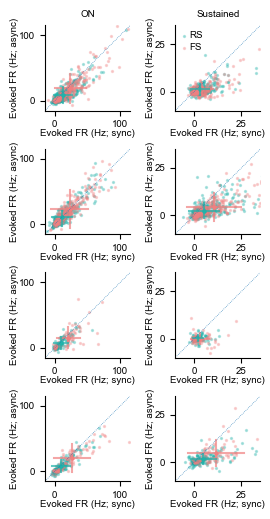

In [16]:
### Fig 5B scatter plots (FP and HP)

f, ax = plt.subplots(4,2, figsize=[2.8,5.2])
scatter_size = 2

alpha_scatter = 0.3
alpha_sd = 0.7
color_FS = "lightcoral"
color_RS = "lightseagreen"

for i in [0,2]: # row 0/1 FP, 2/3 HP
    if i == 0:
        group1 = 'TrkC'
        group2 = 'TrkB'
        mfr_df = mfr_df_FP
        mfr_mice_df = mfr_mice_df_FP
        order_x = ['TrkC','TrkB']
    elif i == 2:
        group1 = 'TrkC_S1HP'
        group2 = 'TrkB_S1HP'
        mfr_df = mfr_df_HP
        mfr_mice_df = mfr_mice_df_HP
        order_x =  ['TrkC_S1HP','TrkB_S1HP']

    ax[i,0].scatter(units_dfr_sync_on[group1][units_selected_RS[group1]],units_dfr_async_on[group1][units_selected_RS[group1]], c=color_RS,s=scatter_size, alpha=alpha_scatter)
    ax[i,0].scatter(units_dfr_sync_on[group1][units_selected_FS[group1]],units_dfr_async_on[group1][units_selected_FS[group1]], c=color_FS,s=scatter_size, alpha=alpha_scatter)
    ax[i,1].scatter(units_dfr_sync_sus[group1][units_selected_RS[group1]],units_dfr_async_sus[group1][units_selected_RS[group1]],label='RS', c=color_RS,s=scatter_size, alpha=alpha_scatter)
    ax[i,1].scatter(units_dfr_sync_sus[group1][units_selected_FS[group1]],units_dfr_async_sus[group1][units_selected_FS[group1]],label='FS', c=color_FS,s=scatter_size, alpha=alpha_scatter)

    ax[i+1,0].scatter(units_dfr_sync_on[group2][units_selected_RS[group2]],units_dfr_async_on[group2][units_selected_RS[group2]], c=color_RS,s=scatter_size, alpha=alpha_scatter)
    ax[i+1,0].scatter(units_dfr_sync_on[group2][units_selected_FS[group2]],units_dfr_async_on[group2][units_selected_FS[group2]], c=color_FS,s=scatter_size, alpha=alpha_scatter)
    ax[i+1,1].scatter(units_dfr_sync_sus[group2][units_selected_RS[group2]],units_dfr_async_sus[group2][units_selected_RS[group2]], c=color_RS,s=scatter_size, alpha=alpha_scatter)
    ax[i+1,1].scatter(units_dfr_sync_sus[group2][units_selected_FS[group2]],units_dfr_async_sus[group2][units_selected_FS[group2]], c=color_FS,s=scatter_size, alpha=alpha_scatter)

    ax[i,0].scatter(dfr_plot[group1]['dfr_mean_sync_on_FS'],dfr_plot[group1]['dfr_mean_async_on_FS'], color = color_FS, s=5)
    ax[i,0].plot(dfr_plot[group1]['dfr_range_sync_on_FS'], [dfr_plot[group1]['dfr_mean_async_on_FS'],dfr_plot[group1]['dfr_mean_async_on_FS']], color = color_FS, alpha = alpha_sd)
    ax[i,0].plot([dfr_plot[group1]['dfr_mean_sync_on_FS'],dfr_plot[group1]['dfr_mean_sync_on_FS']],dfr_plot[group1]['dfr_range_async_on_FS'], color = color_FS, alpha = alpha_sd)

    ax[i,0].scatter(dfr_plot[group1]['dfr_mean_sync_on_RS'],dfr_plot[group1]['dfr_mean_async_on_RS'], color = color_RS, s=5)
    ax[i,0].plot(dfr_plot[group1]['dfr_range_sync_on_RS'], [dfr_plot[group1]['dfr_mean_async_on_RS'],dfr_plot[group1]['dfr_mean_async_on_RS']], color = color_RS, alpha = alpha_sd)
    ax[i,0].plot([dfr_plot[group1]['dfr_mean_sync_on_RS'],dfr_plot[group1]['dfr_mean_sync_on_RS']],dfr_plot[group1]['dfr_range_async_on_RS'], color = color_RS, alpha = alpha_sd)

    ax[i,1].scatter(dfr_plot[group1]['dfr_mean_sync_sus_FS'],dfr_plot[group1]['dfr_mean_async_sus_FS'], color = color_FS, s=5)
    ax[i,1].plot(dfr_plot[group1]['dfr_range_sync_sus_FS'], [dfr_plot[group1]['dfr_mean_async_sus_FS'],dfr_plot[group1]['dfr_mean_async_sus_FS']], color = color_FS, alpha = alpha_sd)
    ax[i,1].plot([dfr_plot[group1]['dfr_mean_sync_sus_FS'],dfr_plot[group1]['dfr_mean_sync_sus_FS']],dfr_plot[group1]['dfr_range_async_sus_FS'], color = color_FS, alpha = alpha_sd)

    ax[i,1].scatter(dfr_plot[group1]['dfr_mean_sync_sus_RS'],dfr_plot[group1]['dfr_mean_async_sus_RS'], color = color_RS, s=5)
    ax[i,1].plot(dfr_plot[group1]['dfr_range_sync_sus_RS'], [dfr_plot[group1]['dfr_mean_async_sus_RS'],dfr_plot[group1]['dfr_mean_async_sus_RS']], color = color_RS, alpha = alpha_sd)
    ax[i,1].plot([dfr_plot[group1]['dfr_mean_sync_sus_RS'],dfr_plot[group1]['dfr_mean_sync_sus_RS']],dfr_plot[group1]['dfr_range_async_sus_RS'], color = color_RS, alpha = alpha_sd)

    ax[i+1,0].scatter(dfr_plot[group2]['dfr_mean_sync_on_FS'],dfr_plot[group2]['dfr_mean_async_on_FS'], color = color_FS, s=5)
    ax[i+1,0].plot(dfr_plot[group2]['dfr_range_sync_on_FS'], [dfr_plot[group2]['dfr_mean_async_on_FS'],dfr_plot[group2]['dfr_mean_async_on_FS']], color = color_FS, alpha = alpha_sd)
    ax[i+1,0].plot([dfr_plot[group2]['dfr_mean_sync_on_FS'],dfr_plot[group2]['dfr_mean_sync_on_FS']],dfr_plot[group2]['dfr_range_async_on_FS'], color = color_FS, alpha = alpha_sd)

    ax[i+1,0].scatter(dfr_plot[group2]['dfr_mean_sync_on_RS'],dfr_plot[group2]['dfr_mean_async_on_RS'], color = color_RS, s=5)
    ax[i+1,0].plot(dfr_plot[group2]['dfr_range_sync_on_RS'], [dfr_plot[group2]['dfr_mean_async_on_RS'],dfr_plot[group2]['dfr_mean_async_on_RS']], color = color_RS, alpha = alpha_sd)
    ax[i+1,0].plot([dfr_plot[group2]['dfr_mean_sync_on_RS'],dfr_plot[group2]['dfr_mean_sync_on_RS']],dfr_plot[group1]['dfr_range_async_on_RS'], color = color_RS, alpha = alpha_sd)

    ax[i+1,1].scatter(dfr_plot[group2]['dfr_mean_sync_sus_FS'],dfr_plot[group2]['dfr_mean_async_sus_FS'], color = color_FS, s=5)
    ax[i+1,1].plot(dfr_plot[group2]['dfr_range_sync_sus_FS'], [dfr_plot[group2]['dfr_mean_async_sus_FS'],dfr_plot[group2]['dfr_mean_async_sus_FS']], color = color_FS, alpha = alpha_sd)
    ax[i+1,1].plot([dfr_plot[group2]['dfr_mean_sync_sus_FS'],dfr_plot[group2]['dfr_mean_sync_sus_FS']],dfr_plot[group2]['dfr_range_async_sus_FS'], color = color_FS, alpha = alpha_sd)

    ax[i+1,1].scatter(dfr_plot[group2]['dfr_mean_sync_sus_RS'],dfr_plot[group2]['dfr_mean_async_sus_RS'], color = color_RS, s=5)
    ax[i+1,1].plot(dfr_plot[group2]['dfr_range_sync_sus_RS'], [dfr_plot[group2]['dfr_mean_async_sus_RS'],dfr_plot[group2]['dfr_mean_async_sus_RS']], color = color_RS, alpha = alpha_sd)
    ax[i+1,1].plot([dfr_plot[group2]['dfr_mean_sync_sus_RS'],dfr_plot[group2]['dfr_mean_sync_sus_RS']],dfr_plot[group2]['dfr_range_async_sus_RS'], color = color_RS, alpha = alpha_sd)

for i in range(8):
    ax[i//2, i%2].plot([-200,200],[-200,200],linestyle = ':', linewidth=0.5)
    ax[i//2, i%2].spines['top'].set_visible(False)
    ax[i//2, i%2].spines['right'].set_visible(False)
    ax[i//2, i%2].set_aspect('equal',adjustable='box')

for i in [0,1,2,3]:
    ax[i,0].set_xlim([-15,115])
    ax[i,0].set_ylim([-15,115])
    ax[i,0].set_xticks([0,100])
    ax[i,0].set_xticklabels([0,100])
    ax[i,0].set_yticks([0,100])
    ax[i,0].set_yticklabels([0,100])
    ax[i,0].set_xlabel('Evoked FR (Hz; sync)', labelpad = 0)
    ax[i,0].set_ylabel('Evoked FR (Hz; async)', labelpad = 0)    

    ax[i,1].set_xlim([-10,35])
    ax[i,1].set_ylim([-10,35])
    ax[i,1].set_xticks([0,25])
    ax[i,1].set_xticklabels([0,25])
    ax[i,1].set_yticks([0,25])
    ax[i,1].set_yticklabels([0,25])
    ax[i,1].set_xlabel('Evoked FR (Hz; sync)', labelpad = 0)
    ax[i,1].set_ylabel('Evoked FR (Hz; async)', labelpad = 0)

ax[0,1].legend(borderpad=0.1,      # Fractional whitespace inside the legend border
    labelspacing=0.3,   # Vertical space between entries
    handlelength=0.7,   # Length of the legend handles (lines/markers)
    handletextpad=0.2,  # Pad between handle and text
    columnspacing=0.5,  # Spacing between columns (if ncol > 1),
    loc = 'upper left',
    frameon=False)

ax[0,0].set_title('ON', fontsize=7)
ax[0,1].set_title('Sustained', fontsize=7)

plt.subplots_adjust(hspace=0.2, wspace=0.3)
plt.tight_layout()
# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures2\scatter_dfr_5.2.pdf",dpi=600,bbox_inches='tight',transparent=True)

plt.show()

In [17]:
# for Fig 6 df for diff FR for cell types
mfr_df_diff_groups = {}
mfr_df_diff_celltype_mice_groups = {}

for igroup in recording_groups:
    units_type = units_selected_type[igroup]
    mfr_df = mfr_dfs[igroup]
    mfr_df_sync = mfr_df[mfr_df['cond']=='sync']
    mfr_df_async = mfr_df[mfr_df['cond']=='async']
    mfr_df_diff = mfr_df_sync.copy()
    mfr_df_diff['diffON'] = np.array(mfr_df_sync['mfrON']) - np.array(mfr_df_async['mfrON'])
    mfr_df_diff['diffSUS'] = np.array(mfr_df_sync['mfrSUS']) - np.array(mfr_df_async['mfrSUS'])
    mfr_df_diff['cellType'] = units_type
    mfr_df_diff_groups[igroup] = mfr_df_diff

    mfr_df_diff_celltype_mice = mfr_df_diff.groupby(['genoGroup','animalID','cellType'], as_index=False)[['diffON','diffSUS']].mean()
    mfr_df_diff_celltype_mice_groups[igroup] = mfr_df_diff_celltype_mice
    
mfr_df_diff_FP = pd.concat((mfr_df_diff_groups['TrkC'], mfr_df_diff_groups['TrkB']))
mfr_df_diff_HP = pd.concat((mfr_df_diff_groups['TrkC_S1HP'], mfr_df_diff_groups['TrkB_S1HP']))

mfr_df_diff_celltype_mice_FP = pd.concat((mfr_df_diff_celltype_mice_groups['TrkC'], mfr_df_diff_celltype_mice_groups['TrkB']))
mfr_df_diff_celltype_mice_HP = pd.concat((mfr_df_diff_celltype_mice_groups['TrkC_S1HP'], mfr_df_diff_celltype_mice_groups['TrkB_S1HP']))

C:\Users\ajemanu\AppData\Local\Temp\ipykernel_34840\1003941185.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mice_TrkC['sex'] = df_mice_TrkC['animalID'].map(sex_map)
C:\Users\ajemanu\AppData\Local\Temp\ipykernel_34840\1003941185.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mice_TrkB['sex'] = df_mice_TrkB['animalID'].map(sex_map)
C:\Users\ajemanu\AppData\Local\Temp\ipykernel_34840\1003941185.py:214: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is 

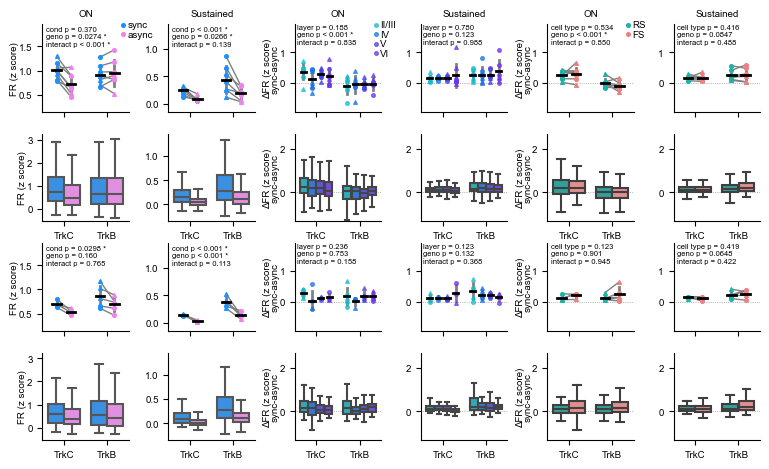

In [18]:
# Fig 6 box plots and dots - add p value

sync_color = 'dodgerblue'
async_color = 'violet'
line_color = 'grey'
mean_color = 'black'
FS_color = "lightcoral"
RS_color = "lightseagreen"

colorpal = {'sync':sync_color, 'async':async_color}
hue_order_cond = ['sync','async']

colorpal_celltype = {'RS':RS_color, 'FS':FS_color}
hue_order_celltype = ['RS','FS']

markersize = 7
mwidth = 0.3 # half of the mean bar
star_size = 6
pval_size = 5.5 # text size for pval
star_font = 'Consolas'
p_font = 'Arial'
mark_male = '^'
mark_female = 'o'
mark_map = {'Male':'^', 'Female':'o'}
alpha_layers = 0.7

x_plot = np.array([1,2,4,5]) # x value for TrkC-sync, TrkC-async, TrkB-sync, TrkB-async - also for cell types
x_layers = [1,2,3,4, 6,7,8,9] # x values for plotting layers

plot_var = ['mfrON', 'mfrSUS'] # variables to plot - mice
plot_var_diff = ['diffON', 'diffSUS'] # variables to plot

layers_list = ['l23', 'l4', 'l5', 'l6']
hue_order_layers = ['l23', 'l4', 'l5', 'l6']

colorpal_layers = {'l23':'#17becf', 'l4':'#1a75ed', 'l5':'#4a42e8','l6':'#6D35EE'}
colorpal_layers_scatter = {'l23':'#222222', 'l4':'#222222', 'l5':'#222222', 'l6':'#222222'}
labeltext_layers = {'l23':'II/III', 'l4':'IV', 'l5':'V','l6':'VI'}

zorder_line = 1
zorder_dots = 7
zorder_mean = 15

f, ax = plt.subplots(4,6, figsize=[7.5,4.5])

for i in [2,3,4,5, 8,9,10,11, 14,15,16,17, 20,21,22,23]: # line 0 for diff zfr
    ax[i//6, i%6].axhline(0, color='grey', linestyle=':', linewidth=0.5,zorder=0)

# box plot sync vs async
for irow in [0,2]: # 0/1 FP 2/3 HP
    if irow == 0:
        group1 = 'TrkC'
        group2 = 'TrkB'
        mfr_df = mfr_df_FP.copy()
        df_mice = mfr_mice_df_FP.copy()
        diff_df_celltype = mfr_df_diff_FP.copy()
        diff_df_mice_celltype = mfr_df_diff_celltype_mice_FP.copy()
        order_x = ['TrkC','TrkB']
    elif irow == 2:
        group1 = 'TrkC_S1HP'
        group2 = 'TrkB_S1HP'
        mfr_df = mfr_df_HP.copy()
        df_mice = mfr_mice_df_HP.copy()
        diff_df_celltype = mfr_df_diff_HP.copy()
        diff_df_mice_celltype = mfr_df_diff_celltype_mice_HP.copy()
        order_x =  ['TrkC_S1HP','TrkB_S1HP']

    # plot sync vs async S1 units 0,1,8,9
    sns.boxplot(ax=ax[irow+1,0],x='genoGroup', y='mfrON', hue='cond', data=mfr_df, order = order_x,hue_order=hue_order_cond, width=0.75,showfliers=False, palette = colorpal)
    sns.boxplot(ax=ax[irow+1,1],x='genoGroup', y='mfrSUS', hue='cond', data=mfr_df, order = order_x,hue_order=hue_order_cond, width=0.75,showfliers=False, palette = colorpal)

    # plot dzfr by layers 2,3,14,15
    mfr_diff_layers = {}
    mfr_diff_layers_mice = {}

    for i,ilayer in enumerate(layers_list):

        mfr_df_ilayer = mfr_df[(mfr_df['layer']==ilayer)]
        mfr_df_ilayer_sync = mfr_df_ilayer[mfr_df_ilayer['cond'] == 'sync']
        mfr_df_ilayer_async = mfr_df_ilayer[mfr_df_ilayer['cond'] == 'async']

        mfr_df_ilayer_diff = mfr_df_ilayer_sync[['unitGroup','genoGroup','animalID','cond']].copy()
        mfr_df_ilayer_diff['diffON'] = np.array(mfr_df_ilayer_sync['mfrON']) - np.array(mfr_df_ilayer_async['mfrON'])
        mfr_df_ilayer_diff['diffSUS'] = np.array(mfr_df_ilayer_sync['mfrSUS']) - np.array(mfr_df_ilayer_async['mfrSUS'])
        mfr_df_ilayer_diff['layer'] = ilayer

        mfr_df_ilayer_diff_mice = mfr_df_ilayer_diff.groupby(['genoGroup','animalID','cond'], as_index=False)[['diffON','diffSUS']].mean()
        mfr_df_ilayer_diff_mice['layer'] = ilayer

        mfr_diff_layers[ilayer] = mfr_df_ilayer_diff
        mfr_diff_layers_mice[ilayer] = mfr_df_ilayer_diff_mice

    mfr_diff_layers_concat = pd.concat(mfr_diff_layers)
    mfr_diff_layers_mice_concat = pd.concat(mfr_diff_layers_mice)

    sns.boxplot(ax=ax[irow+1,2],x='genoGroup', y='diffON', hue='layer',data=mfr_diff_layers_concat,order=order_x, width=0.75,showfliers=False,palette=colorpal_layers)
    sns.boxplot(ax=ax[irow+1,3],x='genoGroup', y='diffSUS', hue='layer',data=mfr_diff_layers_concat,order=order_x, width=0.75,showfliers=False,palette=colorpal_layers)

    # plot dzfr by cell type
    sns.boxplot(ax=ax[irow+1,4],x='genoGroup', y='diffON', hue='cellType',data=diff_df_celltype,order=order_x,hue_order=hue_order_celltype, width=0.75,showfliers=False,palette=colorpal_celltype)
    sns.boxplot(ax=ax[irow+1,5],x='genoGroup', y='diffSUS', hue='cellType',data=diff_df_celltype,order=order_x,hue_order=hue_order_celltype, width=0.75,showfliers=False,palette=colorpal_celltype)

##### plot sync vs async mice 6,7,18,19
    df_mice_TrkC = df_mice[df_mice['genoGroup'].isin(['TrkC','TrkC_S1HP'])]
    df_mice_TrkB = df_mice[df_mice['genoGroup'].isin(['TrkB','TrkB_S1HP'])]

    df_mice_TrkC['sex'] = df_mice_TrkC['animalID'].map(sex_map)
    df_mice_TrkB['sex'] = df_mice_TrkB['animalID'].map(sex_map)

    df_mice_TrkC_sync = df_mice_TrkC[df_mice_TrkC['cond']=='sync']
    df_mice_TrkB_sync = df_mice_TrkB[df_mice_TrkB['cond']=='sync']

    females_TrkC = np.where(df_mice_TrkC_sync['sex'] == 'Female')[0] # idx of which are females
    males_TrkC = np.where(df_mice_TrkC_sync['sex'] == 'Male')[0]
    females_TrkB = np.where(df_mice_TrkB_sync['sex'] == 'Female')[0]
    males_TrkB = np.where(df_mice_TrkB_sync['sex'] == 'Male')[0]

    for ivar, frvar in enumerate(plot_var):
        sync_TrkC_array = np.array(df_mice_TrkC[df_mice_TrkC['cond']=='sync'][frvar])
        async_TrkC_array = np.array(df_mice_TrkC[df_mice_TrkC['cond']=='async'][frvar])
        sync_TrkB_array = np.array(df_mice_TrkB[df_mice_TrkB['cond']=='sync'][frvar])
        async_TrkB_array = np.array(df_mice_TrkB[df_mice_TrkB['cond']=='async'][frvar])

        n_TrkC = len(sync_TrkC_array) # number of animals per geno
        n_TrkB = len(sync_TrkB_array)

        x1_TrkC_array = np.repeat(x_plot[0], n_TrkC)
        x2_TrkC_array = np.repeat(x_plot[1], n_TrkC)
        x1_TrkB_array = np.repeat(x_plot[2], n_TrkB)
        x2_TrkB_array = np.repeat(x_plot[3], n_TrkB)

        ax[irow,ivar].plot([x1_TrkC_array,x2_TrkC_array], [sync_TrkC_array,async_TrkC_array],c=line_color,lw=1,zorder=zorder_line)
        ax[irow,ivar].plot([x1_TrkB_array,x2_TrkB_array], [sync_TrkB_array,async_TrkB_array],c=line_color,lw=1,zorder=zorder_line)

        ax[irow,ivar].scatter(x1_TrkC_array[females_TrkC],sync_TrkC_array[females_TrkC],s=markersize,marker=mark_female,c=sync_color,zorder=zorder_dots, label='sync')
        ax[irow,ivar].scatter(x1_TrkC_array[males_TrkC],sync_TrkC_array[males_TrkC],s=markersize,marker=mark_male,c=sync_color,zorder=zorder_dots)
        ax[irow,ivar].scatter(x2_TrkC_array[females_TrkC],async_TrkC_array[females_TrkC],s=markersize,marker=mark_female,c=async_color,zorder=zorder_dots, label='async')
        ax[irow,ivar].scatter(x2_TrkC_array[males_TrkC],async_TrkC_array[males_TrkC],s=markersize,marker=mark_male,c=async_color,zorder=zorder_dots)
        ax[irow,ivar].scatter(x1_TrkB_array[females_TrkB],sync_TrkB_array[females_TrkB],s=markersize,marker=mark_female,c=sync_color,zorder=zorder_dots)
        ax[irow,ivar].scatter(x1_TrkB_array[males_TrkB],sync_TrkB_array[males_TrkB],s=markersize,marker=mark_male,c=sync_color,zorder=zorder_dots)
        ax[irow,ivar].scatter(x2_TrkB_array[females_TrkB],async_TrkB_array[females_TrkB],s=markersize,marker=mark_female,c=async_color,zorder=zorder_dots)
        ax[irow,ivar].scatter(x2_TrkB_array[males_TrkB],async_TrkB_array[males_TrkB],s=markersize,marker=mark_male,c=async_color,zorder=zorder_dots)

        ax[irow,ivar].plot([x_plot[0]-mwidth,x_plot[0]+mwidth], [np.mean(sync_TrkC_array),np.mean(sync_TrkC_array)],c=mean_color,lw=2,zorder=zorder_mean)
        ax[irow,ivar].plot([x_plot[1]-mwidth,x_plot[1]+mwidth], [np.mean(async_TrkC_array),np.mean(async_TrkC_array)],c=mean_color,lw=2,zorder=zorder_mean)
        ax[irow,ivar].plot([x_plot[2]-mwidth,x_plot[2]+mwidth], [np.mean(sync_TrkB_array),np.mean(sync_TrkB_array)],c=mean_color,lw=2,zorder=zorder_mean)
        ax[irow,ivar].plot([x_plot[3]-mwidth,x_plot[3]+mwidth], [np.mean(async_TrkB_array),np.mean(async_TrkB_array)],c=mean_color,lw=2,zorder=zorder_mean)
    
        ax[irow,ivar].plot([x_plot[0],x_plot[0]], [np.mean(sync_TrkC_array)-np.std(sync_TrkC_array),np.mean(sync_TrkC_array)+np.std(sync_TrkC_array)],c=line_color,lw=2,zorder=zorder_line)
        ax[irow,ivar].plot([x_plot[1],x_plot[1]], [np.mean(async_TrkC_array)-np.std(async_TrkC_array),np.mean(async_TrkC_array)+np.std(async_TrkC_array)],c=line_color,lw=2,zorder=zorder_line)
        ax[irow,ivar].plot([x_plot[2],x_plot[2]], [np.mean(sync_TrkB_array)-np.std(sync_TrkB_array),np.mean(sync_TrkB_array)+np.std(sync_TrkB_array)],c=line_color,lw=2,zorder=zorder_line)
        ax[irow,ivar].plot([x_plot[3],x_plot[3]], [np.mean(async_TrkB_array)-np.std(async_TrkB_array),np.mean(async_TrkB_array)+np.std(async_TrkB_array)],c=line_color,lw=2,zorder=zorder_line)

##### plot sync vs async mice

##### plot layers mice 8,9,20,21
    mfr_diff_layers = {}
    mfr_diff_layers_mice = {}
    mfr_diff_layers_concat = pd.DataFrame(columns=['unitGroup','genoGroup','animalID','cond','diffON','diffSUS','layer'])
    mfr_diff_layers_mice_concat = pd.DataFrame(columns=['genoGroup','animalID','cond','diffON','diffSUS','layer'])

    for i,ilayer in enumerate(layers_list):

        mfr_df_ilayer = mfr_df[(mfr_df['layer']==ilayer)]
        mfr_df_ilayer_sync = mfr_df_ilayer[mfr_df_ilayer['cond'] == 'sync']
        mfr_df_ilayer_async = mfr_df_ilayer[mfr_df_ilayer['cond'] == 'async']

        mfr_df_ilayer_diff = mfr_df_ilayer_sync[['unitGroup','genoGroup','animalID','cond']].copy()
        mfr_df_ilayer_diff['diffON'] = np.array(mfr_df_ilayer_sync['mfrON']) - np.array(mfr_df_ilayer_async['mfrON'])
        mfr_df_ilayer_diff['diffSUS'] = np.array(mfr_df_ilayer_sync['mfrSUS']) - np.array(mfr_df_ilayer_async['mfrSUS'])
        mfr_df_ilayer_diff['layer'] = ilayer

        mfr_df_ilayer_diff_mice = mfr_df_ilayer_diff.groupby(['genoGroup','animalID','cond'], as_index=False)[['diffON','diffSUS']].mean()
        mfr_df_ilayer_diff_mice['layer'] = ilayer

        mfr_diff_layers[ilayer] = mfr_df_ilayer_diff
        mfr_diff_layers_mice[ilayer] = mfr_df_ilayer_diff_mice
        mfr_df_ilayer_diff_mice['sex'] = mfr_df_ilayer_diff_mice['animalID'].map(sex_map)

        mfr_df_ilayer_diff_mice_TrkC = mfr_df_ilayer_diff_mice[mfr_df_ilayer_diff_mice['genoGroup'].isin(['TrkC','TrkC_S1HP'])]
        mfr_df_ilayer_diff_mice_TrkB = mfr_df_ilayer_diff_mice[mfr_df_ilayer_diff_mice['genoGroup'].isin(['TrkB','TrkB_S1HP'])]

        n_TrkC = len(mfr_df_ilayer_diff_mice_TrkC) # number of animals per geno
        n_TrkB = len(mfr_df_ilayer_diff_mice_TrkB)
        
        ilayer_females_TrkC = np.where(mfr_df_ilayer_diff_mice_TrkC['sex'] == 'Female')[0] # idx of which are females
        ilayer_males_TrkC = np.where(mfr_df_ilayer_diff_mice_TrkC['sex'] == 'Male')[0]
        ilayer_females_TrkB = np.where(mfr_df_ilayer_diff_mice_TrkB['sex'] == 'Female')[0]
        ilayer_males_TrkB = np.where(mfr_df_ilayer_diff_mice_TrkB['sex'] == 'Male')[0]
        # print(len(ilayer_females_TrkC),len(ilayer_males_TrkC),len(ilayer_females_TrkB),len(ilayer_males_TrkB))

        x_ilayer_TrkC = x_layers[i] # the x value for plotting
        x_ilayer_TrkB = x_layers[i+4]

        x_ilayer_TrkC_array = np.repeat(x_ilayer_TrkC, n_TrkC)
        x_ilayer_TrkB_array = np.repeat(x_ilayer_TrkB, n_TrkB)

        for jvar, diffvar in enumerate(plot_var_diff):
            ilayer_diff_TrkC_array = np.array(mfr_df_ilayer_diff_mice_TrkC[diffvar])
            ilayer_diff_TrkB_array = np.array(mfr_df_ilayer_diff_mice_TrkB[diffvar])
            ax[irow,jvar+2].plot([x_ilayer_TrkC,x_ilayer_TrkC], [np.mean(ilayer_diff_TrkC_array)-np.std(ilayer_diff_TrkC_array),np.mean(ilayer_diff_TrkC_array)+np.std(ilayer_diff_TrkC_array)],c=line_color,lw=2,zorder=zorder_line)
            ax[irow,jvar+2].plot([x_ilayer_TrkB,x_ilayer_TrkB], [np.mean(ilayer_diff_TrkB_array)-np.std(ilayer_diff_TrkB_array),np.mean(ilayer_diff_TrkB_array)+np.std(ilayer_diff_TrkB_array)],c=line_color,lw=2,zorder=zorder_line)

            ax[irow,jvar+2].scatter(x_ilayer_TrkC_array[ilayer_females_TrkC],ilayer_diff_TrkC_array[ilayer_females_TrkC],s=markersize,marker=mark_female,c=colorpal_layers[ilayer],alpha=alpha_layers,label=labeltext_layers[ilayer])
            ax[irow,jvar+2].scatter(x_ilayer_TrkC_array[ilayer_males_TrkC],ilayer_diff_TrkC_array[ilayer_males_TrkC],s=markersize,marker=mark_male,c=colorpal_layers[ilayer],alpha=alpha_layers)
            ax[irow,jvar+2].scatter(x_ilayer_TrkB_array[ilayer_females_TrkB],ilayer_diff_TrkB_array[ilayer_females_TrkB],s=markersize,marker=mark_female,c=colorpal_layers[ilayer],alpha=alpha_layers)
            ax[irow,jvar+2].scatter(x_ilayer_TrkB_array[ilayer_males_TrkB],ilayer_diff_TrkB_array[ilayer_males_TrkB],s=markersize,marker=mark_male,c=colorpal_layers[ilayer],alpha=alpha_layers)

            ax[irow,jvar+2].plot([x_ilayer_TrkC-mwidth,x_ilayer_TrkC+mwidth], [np.mean(ilayer_diff_TrkC_array),np.mean(ilayer_diff_TrkC_array)],c=mean_color,lw=2,zorder=zorder_mean)
            ax[irow,jvar+2].plot([x_ilayer_TrkB-mwidth,x_ilayer_TrkB+mwidth], [np.mean(ilayer_diff_TrkB_array),np.mean(ilayer_diff_TrkB_array)],c=mean_color,lw=2,zorder=zorder_mean)



        mfr_diff_layers_concat = pd.concat([mfr_diff_layers_concat,mfr_df_ilayer_diff])
        mfr_diff_layers_mice_concat = pd.concat([mfr_diff_layers_mice_concat,mfr_df_ilayer_diff_mice])
##### plot layers mice

##### plot celltype mice
    diff_df_mice_TrkC = diff_df_mice_celltype[diff_df_mice_celltype['genoGroup'].isin(['TrkC','TrkC_S1HP'])]
    diff_df_mice_TrkB = diff_df_mice_celltype[diff_df_mice_celltype['genoGroup'].isin(['TrkB','TrkB_S1HP'])]

    diff_df_mice_TrkC['sex'] = diff_df_mice_TrkC['animalID'].map(sex_map)
    diff_df_mice_TrkB['sex'] = diff_df_mice_TrkB['animalID'].map(sex_map)

    diff_df_mice_TrkC_RS = diff_df_mice_TrkC[diff_df_mice_TrkC['cellType']=='RS']
    diff_df_mice_TrkB_RS = diff_df_mice_TrkB[diff_df_mice_TrkB['cellType']=='RS']

    females_TrkC1 = np.where(diff_df_mice_TrkC_RS['sex'] == 'Female')[0] # idx of which are females
    males_TrkC1 = np.where(diff_df_mice_TrkC_RS['sex'] == 'Male')[0]
    females_TrkB1 = np.where(diff_df_mice_TrkB_RS['sex'] == 'Female')[0]
    males_TrkB1 = np.where(diff_df_mice_TrkB_RS['sex'] == 'Male')[0]

    for ivar, frvar in enumerate(plot_var_diff):
        RS_TrkC_array = np.array(diff_df_mice_TrkC[diff_df_mice_TrkC['cellType']=='RS'][frvar])
        FS_TrkC_array = np.array(diff_df_mice_TrkC[diff_df_mice_TrkC['cellType']=='FS'][frvar])
        RS_TrkB_array = np.array(diff_df_mice_TrkB[diff_df_mice_TrkB['cellType']=='RS'][frvar])
        FS_TrkB_array = np.array(diff_df_mice_TrkB[diff_df_mice_TrkB['cellType']=='FS'][frvar])

        n_TrkC = len(RS_TrkC_array) # number of animals per geno
        n_TrkB = len(RS_TrkB_array)

        x1_TrkC_array = np.repeat(x_plot[0], n_TrkC)
        x2_TrkC_array = np.repeat(x_plot[1], n_TrkC)
        x1_TrkB_array = np.repeat(x_plot[2], n_TrkB)
        x2_TrkB_array = np.repeat(x_plot[3], n_TrkB)

        ax[irow,ivar+4].plot([x1_TrkC_array,x2_TrkC_array], [RS_TrkC_array,FS_TrkC_array],c=line_color,lw=1,zorder=zorder_line)
        ax[irow,ivar+4].plot([x1_TrkB_array,x2_TrkB_array], [RS_TrkB_array,FS_TrkB_array],c=line_color,lw=1,zorder=zorder_line)

        ax[irow,ivar+4].scatter(x1_TrkC_array[females_TrkC1],RS_TrkC_array[females_TrkC1],s=markersize,marker=mark_female,c=RS_color,zorder=zorder_dots, label='RS')
        ax[irow,ivar+4].scatter(x1_TrkC_array[males_TrkC1],RS_TrkC_array[males_TrkC1],s=markersize,marker=mark_male,c=RS_color,zorder=zorder_dots)
        ax[irow,ivar+4].scatter(x2_TrkC_array[females_TrkC1],FS_TrkC_array[females_TrkC1],s=markersize,marker=mark_female,c=FS_color,zorder=zorder_dots, label='FS')
        ax[irow,ivar+4].scatter(x2_TrkC_array[males_TrkC1],FS_TrkC_array[males_TrkC1],s=markersize,marker=mark_male,c=FS_color,zorder=zorder_dots)
        ax[irow,ivar+4].scatter(x1_TrkB_array[females_TrkB1],RS_TrkB_array[females_TrkB1],s=markersize,marker=mark_female,c=RS_color,zorder=zorder_dots)
        ax[irow,ivar+4].scatter(x1_TrkB_array[males_TrkB1],RS_TrkB_array[males_TrkB1],s=markersize,marker=mark_male,c=RS_color,zorder=zorder_dots)
        ax[irow,ivar+4].scatter(x2_TrkB_array[females_TrkB1],FS_TrkB_array[females_TrkB1],s=markersize,marker=mark_female,c=FS_color,zorder=zorder_dots)
        ax[irow,ivar+4].scatter(x2_TrkB_array[males_TrkB1],FS_TrkB_array[males_TrkB1],s=markersize,marker=mark_male,c=FS_color,zorder=zorder_dots)

        ax[irow,ivar+4].plot([x_plot[0]-mwidth,x_plot[0]+mwidth], [np.mean(RS_TrkC_array),np.mean(RS_TrkC_array)],c=mean_color,lw=2,zorder=zorder_mean)
        ax[irow,ivar+4].plot([x_plot[1]-mwidth,x_plot[1]+mwidth], [np.mean(FS_TrkC_array),np.mean(FS_TrkC_array)],c=mean_color,lw=2,zorder=zorder_mean)
        ax[irow,ivar+4].plot([x_plot[2]-mwidth,x_plot[2]+mwidth], [np.mean(RS_TrkB_array),np.mean(RS_TrkB_array)],c=mean_color,lw=2,zorder=zorder_mean)
        ax[irow,ivar+4].plot([x_plot[3]-mwidth,x_plot[3]+mwidth], [np.mean(FS_TrkB_array),np.mean(FS_TrkB_array)],c=mean_color,lw=2,zorder=zorder_mean)

        ax[irow,ivar+4].plot([x_plot[0],x_plot[0]], [np.mean(RS_TrkC_array)-np.std(RS_TrkC_array),np.mean(RS_TrkC_array)+np.std(RS_TrkC_array)],c=line_color,lw=2,zorder=zorder_line)
        ax[irow,ivar+4].plot([x_plot[1],x_plot[1]], [np.mean(FS_TrkC_array)-np.std(FS_TrkC_array),np.mean(FS_TrkC_array)+np.std(FS_TrkC_array)],c=line_color,lw=2,zorder=zorder_line)
        ax[irow,ivar+4].plot([x_plot[2],x_plot[2]], [np.mean(RS_TrkB_array)-np.std(RS_TrkB_array),np.mean(RS_TrkB_array)+np.std(RS_TrkB_array)],c=line_color,lw=2,zorder=zorder_line)
        ax[irow,ivar+4].plot([x_plot[3],x_plot[3]], [np.mean(FS_TrkB_array)-np.std(FS_TrkB_array),np.mean(FS_TrkB_array)+np.std(FS_TrkB_array)],c=line_color,lw=2,zorder=zorder_line)

##### plot celltype mice

for i in [0,1,4,5, 12,13,16,17]:
    ax[i//6, i%6].set_xlim([0,6])
    ax[i//6, i%6].set_xticks([(x_plot[0]+x_plot[1])/2,(x_plot[2]+x_plot[3])/2])

for i in [2,3, 14,15]:
    ax[i//6, i%6].set_xlim([0,10])
    ax[i//6, i%6].set_xticks([(x_layers[0]+x_layers[3])/2,(x_layers[4]+x_layers[7])/2])

for i in range(24):
    
    ax[i//6, i%6].set_xlabel('', labelpad=0)
    ax[i//6, i%6].spines['top'].set_visible(False)
    ax[i//6, i%6].spines['right'].set_visible(False)

for i in [0,1,2,3,4,5, 12,13,14,15,16,17]:
    ax[i//6, i%6].set_xticklabels('')

for i in [6,7,8,9,10,11,18,19,20,21,22,23]:
    ax[i//6, i%6].get_legend().remove()
    ax[i//6, i%6].set_xticklabels(['TrkC','TrkB'])

for i in np.arange(1,24,2):
    ax[i//6, i%6].set_ylabel('', labelpad=0)

for i in [0,6,12,18]:
    ax[i//6, i%6].set_ylabel('FR (z score)', labelpad=0)
    # ax[i//6, i%6].set_ylabel('Firing rate (z score)', labelpad=0)

for i in [2,4,8,10,14,16,20,22]:
    ax[i//6, i%6].set_ylabel('\u0394FR (z score)\nsync-async', linespacing=0.8,labelpad=0)

for i in [0,2,4]:
    ax[i//6, i%6].legend(borderpad=0.0,      # Fractional whitespace inside the legend border
                         labelspacing=0.05,   # Vertical space between entries
                         handlelength=0.5,   # Length of the legend handles (lines/markers)
                         handletextpad=0.2,  # Pad between handle and text
                         columnspacing=0.5,  # Spacing between columns (if ncol > 1),
                         loc = 'upper left',
                         bbox_to_anchor=(0.85,1.1),
                         frameon=False)

ax[0,0].set_title('ON',fontsize=7)
ax[0,1].set_title('Sustained',fontsize=7)
ax[0,2].set_title('ON',fontsize=7)
ax[0,3].set_title('Sustained',fontsize=7)
ax[0,4].set_title('ON',fontsize=7)
ax[0,5].set_title('Sustained',fontsize=7)

# set ylim
for i in [0,12]:
    ax[i//6, i%6].set_ylim([0.15,1.95])

for i in [1,13]:
    ax[i//6, i%6].set_ylim([-0.15,1.45])

for i in [6,18]:
    ax[i//6, i%6].set_ylim([-0.55,3.25])

for i in [7,19]:
    ax[i//6, i%6].set_ylim([-0.35,1.45])

for i in [2,3,4,5, 14,15,16,17]:
    ax[i//6, i%6].set_ylim([-0.95,1.9])

for i in [8,9,10,11, 20,21,22,23]:
    ax[i//6, i%6].set_ylim([-1.35,2.7])

# add pvalues
ax[0,0].text(x=0.25, y=1.5,s='cond p = 0.370 \ngeno p = 0.0274 *\ninteract p < 0.001 *', size=pval_size,ha='left')
ax[0,1].text(x=0.25, y=1.05, s='cond p < 0.001 *\ngeno p = 0.0266 *\ninteract p = 0.139', size=pval_size,ha='left')
ax[0,2].text(x=0.25, y=1.25, s='layer p = 0.188\ngeno p < 0.001 *\ninteract p = 0.838', size=pval_size,ha='left')
ax[0,3].text(x=0.25, y=1.25, s='layer p = 0.780\ngeno p = 0.123\ninteract p = 0.988', size=pval_size,ha='left')
ax[0,4].text(x=0.25, y=1.25, s='cell type p = 0.534\ngeno p < 0.001 *\ninteract p = 0.850', size=pval_size,ha='left')
ax[0,5].text(x=0.25, y=1.25, s='cell type p = 0.416\ngeno p = 0.0847\ninteract p = 0.488', size=pval_size,ha='left')

ax[2,0].text(x=0.25, y=1.5,s='cond p = 0.0298 *\ngeno p = 0.160\ninteract p = 0.765', size=pval_size,ha='left')
ax[2,1].text(x=0.25, y=1.05, s='cond p < 0.001 *\ngeno p < 0.001 *\ninteract p = 0.113', size=pval_size,ha='left')
ax[2,2].text(x=0.25, y=1.25, s='layer p = 0.236\ngeno p = 0.753\ninteract p = 0.158', size=pval_size,ha='left')
ax[2,3].text(x=0.25, y=1.25, s='layer p = 0.123\ngeno p = 0.132\ninteract p = 0.368', size=pval_size,ha='left')
ax[2,4].text(x=0.25, y=1.25, s='cell type p = 0.123\ngeno p = 0.901\ninteract p = 0.945', size=pval_size,ha='left')
ax[2,5].text(x=0.25, y=1.25, s='cell type p = 0.419\ngeno p = 0.0648\ninteract p = 0.422', size=pval_size,ha='left')


# plt.subplots_adjust(hspace=0.2, wspace=0)
plt.tight_layout(pad=0)

# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures2\sync_layers_box_dots_pval_3.pdf",dpi=600,bbox_inches='tight',transparent=True)

plt.show()